# Polynomial Regression and Regularization

This notebook compares a high-degree polynomial regression model with Ridge, Lasso, and ElasticNet regularization.

We will check:
- Overfitting using train and test RMSE
- Ridge, Lasso, and ElasticNet performance
- Regularization path
- 5-fold cross-validation
- Lasso feature selection

In [94]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error

## 1. Create Dataset

We create a simple dataset where:

\[
y = 3x + noise
\]

The noise is added to make the data slightly realistic.

In [95]:
np.random.seed(42)

x = np.random.randint(1, 100, size=(20, 1))
noise = np.random.randint(1, 10, size=(20, 1))

y = 3 * x + noise
y = y.ravel()

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

## 2. RMSE Function

RMSE means Root Mean Squared Error.

Lower RMSE means better predictions.

In [96]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

## 3. Compare Degree-15 Polynomial Model with Regularized Models

We compare:
- Degree-15 Polynomial Linear Regression
- Ridge Regression
- Lasso Regression
- ElasticNet Regression

A degree-15 polynomial can overfit because it creates many complex features.

In [97]:
models = {
    "Degree 15 Linear Regression": Pipeline([
        ("poly", PolynomialFeatures(degree=15, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Ridge Regression": Pipeline([
        ("poly", PolynomialFeatures(degree=15, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),

    "Lasso Regression": Pipeline([
        ("poly", PolynomialFeatures(degree=15, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.01, max_iter=100000))
    ]),

    "ElasticNet Regression": Pipeline([
        ("poly", PolynomialFeatures(degree=15, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=100000))
    ])
}

for name, model in models.items():
    model.fit(x_train, y_train)

    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    print(name)
    print("Train RMSE:", rmse(y_train, y_train_pred))
    print("Test RMSE:", rmse(y_test, y_test_pred))
    print()

Degree 15 Linear Regression
Train RMSE: 1.185854122563423
Test RMSE: 778.5417153531366

Ridge Regression
Train RMSE: 9.064058444723514
Test RMSE: 14.549594723930479

Lasso Regression
Train RMSE: 2.5227946239901433
Test RMSE: 1.9447191273483957

ElasticNet Regression
Train RMSE: 3.1552950381659057
Test RMSE: 1.0511306308198187



## 4. Regularization Path

Here we plot Ridge coefficients for different alpha values.

As alpha increases, regularization becomes stronger and coefficients shrink.

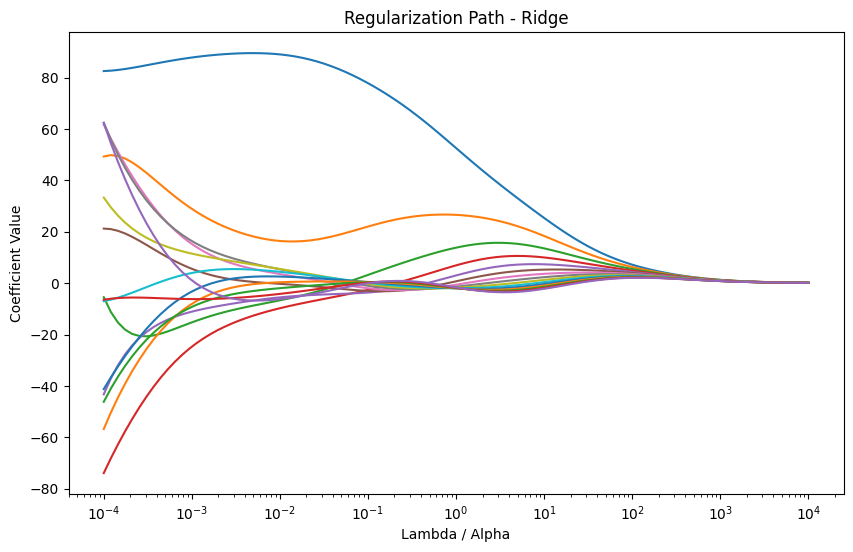

In [98]:
lambdas = np.logspace(-4, 4, 100)
coefficients = []

for alpha in lambdas:
    ridge_path_model = Pipeline([
        ("poly", PolynomialFeatures(degree=15, include_bias=False)),
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=alpha))
    ])

    ridge_path_model.fit(x_train, y_train)
    coefficients.append(ridge_path_model.named_steps["ridge"].coef_)

coefficients = np.array(coefficients)

plt.figure(figsize=(10, 6))
plt.semilogx(lambdas, coefficients)
plt.xlabel("Lambda / Alpha")
plt.ylabel("Coefficient Value")
plt.title("Regularization Path - Ridge")
plt.show()

## 5. 5-Fold Cross Validation

Cross-validation gives a more reliable performance estimate than one train-test split.

In [99]:
cv_model = Pipeline([
    ("poly", PolynomialFeatures(degree=15, include_bias=False)),
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

cv_scores = cross_val_score(
    cv_model,
    x,
    y,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

cv_rmse = -cv_scores

print("CV RMSE scores:", cv_rmse)
print("Mean CV RMSE:", cv_rmse.mean())

CV RMSE scores: [10.2548239   2.4838176   2.35839457 16.11592241 14.14307948]
Mean CV RMSE: 9.071207590708802


## 6. Lasso Zeroed Features

Lasso can shrink some coefficients exactly to zero.  
This means Lasso can perform feature selection.

In [100]:
lasso_model = models["Lasso Regression"]
lasso_coef = lasso_model.named_steps["model"].coef_

zero_features = np.where(lasso_coef == 0)[0]
non_zero_features = np.where(lasso_coef != 0)[0]

print("Zeroed feature indexes:", zero_features)
print("Non-zero feature indexes:", non_zero_features)
print("Number of zeroed features:", len(zero_features))

Zeroed feature indexes: [ 1  2  3  4  8  9 10 11]
Non-zero feature indexes: [ 0  5  6  7 12 13 14]
Number of zeroed features: 8


## Final Observations

The degree-15 polynomial model is very flexible and can overfit small datasets.

Ridge regularization reduces overfitting by shrinking large coefficients.

Lasso also shrinks coefficients and can remove less useful features by making coefficients zero.

ElasticNet combines both Ridge and Lasso regularization.

Cross-validation gives a better idea of model performance than using only one train-test split.